## Configuration

In [1]:

# Event metadata
EVENT_NAME = "2019 Ohio Valley Flood"
EVENT_DATE = "2019-02-12"

# Forecast init
# FORECAST_INIT = "2019-02-12T00:00:00"
# NSTEPS = 12

FORECAST_INIT = "2019-02-10T00:00:00"
NSTEPS = 20

EXTENT = [-95, -75, 30, 42]


OUTPUT_DIR = "ohio_flood_outputs"
ZARR_STORE = f"{OUTPUT_DIR}/graphcast_flood_forecast_5Day.zarr"

POI_LAT = 38.17
POI_LON = 360 - 85.79  # Convert West longitude to 0-360
POI_LABEL = "Louisville, KY"

DATES = ["2019-02-10", "2019-02-11", "2019-02-12", "2019-02-13", "2019-02-14"]

CITIES = [
    {"lat": 39.78, "lon": 360 - 89.65, "label": "Springfield, IL"},
    {"lat": 39.77, "lon": 360 - 86.16, "label": "Indianapolis, IN"},
    {"lat": 39.10, "lon": 360 - 84.51, "label": "Cincinnati, OH"},
    {"lat": 38.63, "lon": 360 - 90.20, "label": "St Louis, MO"},
    {"lat": 38.25, "lon": 360 - 85.76, "label": "Louisville, KY"},
    {"lat": 36.37, "lon": 360 - 94.21, "label": "Bentonville, AR"},
    {"lat": 35.15, "lon": 360 - 90.05, "label": "Memphis, TN"},
]

## Imports

In [2]:
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch

import earth2studio.run as run
from earth2studio.models.px import GraphCastOperational
from earth2studio.data import ARCO
from earth2studio.io import ZarrBackend

warnings.filterwarnings("ignore")
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

/home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature
Device: cuda


## Load Model & Data Source

In [3]:

package = GraphCastOperational.load_default_package()
prognostic_model = GraphCastOperational.load_model(package)


data = ARCO(cache=True, verbose=True)

print("Model and data source loaded.")

Model and data source loaded.


## Run Deterministic Inference

In [4]:
io = ZarrBackend(ZARR_STORE, backend_kwargs={"overwrite": True})

io = run.deterministic(
    [FORECAST_INIT],
    NSTEPS,
    prognostic_model,
    data,
    io,
)

print(io.root.tree())

2026-04-16 16:45:20.835 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-16 16:45:20.835 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching ARCO data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-16 16:45:20.839 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: q850 at 2019-02-09T18:00:00
2026-04-16 16:45:20.841 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: z1000 at 2019-02-09T18:00:00
2026-04-16 16:45:20.842 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: q700 at 2019-02-09T18:00:00
2026-04-16 16:45:20.843 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: q600 at 2019-02-09T18:00:00
2026-04-16 16:45:20.845 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: q500 at 2019-02-09T18:00:00
2026-04-16 16:45:20.846 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: q400 at 2019-02-09T18:00:00
2026-04-16 16:45:20.847 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: q300 at 2019

Fetching ARCO data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-16 16:45:27.116 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: q600 at 2019-02-10T00:00:00
2026-04-16 16:45:27.118 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: z850 at 2019-02-10T00:00:00
2026-04-16 16:45:27.119 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: q925 at 2019-02-10T00:00:00
2026-04-16 16:45:27.120 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: q500 at 2019-02-10T00:00:00
2026-04-16 16:45:27.121 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: q400 at 2019-02-10T00:00:00
2026-04-16 16:45:27.122 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: q300 at 2019-02-10T00:00:00
2026-04-16 16:45:27.123 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: q250 at 2019-

Fetching ARCO data: 100%|██████████| 82/82 [00:06<00:00, 13.44it/s]


2026-04-16 16:45:33.787 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from ARCO
2026-04-16 16:45:33.933 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Running inference:   5%|▍         | 1/21 [00:06<02:00,  6.02s/it]WARNING:absl:Skipping gradient checkpointing for sequence length of 1

Running inference: 100%|██████████| 21/21 [02:23<00:00,  6.85s/it]

2026-04-16 16:47:57.866 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


/
├── lat (721,) float64
├── lead_time (21,) timedelta64
├── lon (1440,) float64
├── msl (1, 21, 721, 1440) float32
├── q100 (1, 21, 721, 1440) float32
├── q1000 (1, 21, 721, 1440) float32
├── q150 (1, 21, 721, 1440) float32
├── q200 (1, 21, 721, 1440) float32
├── q250 (1, 21, 721, 1440) float32
├── q300 (1, 21, 721, 1440) float32
├── q400 (1, 21, 721, 1440) float32
├── q50 (1, 21, 721, 1440) float32
├── q500 (1, 21, 721, 1440) float32
├── q600 (1, 21, 721, 1440) float32
├── q700 (1, 21, 721, 1440) float32
├── q850 (1, 21, 721, 1440) float32
├── q925 (1, 21, 721, 1440) float32
├── t100 (1, 21, 721, 1440) float32
├── t1000 (1, 21, 721, 1440) float32
├── t150 (1, 21, 721, 1440) float32
├── t200 (1, 21, 721, 1440) float32
├── t250 (1, 21, 721, 1440) float32
├── t2m (1, 21, 721, 1440) float32
├── t300 (1, 21, 721, 1440) float32
├── t400 (1, 21, 721, 1440) float32
├── t50 (1, 21, 721, 1440) float32
├── t500 (1, 21, 721, 1440) float32
├── t600 (1, 21, 721, 1440) float32
├── t700 (1, 21, 721, 1440) float32
├── t850 (1, 21, 721, 1440) float32
├── t925 (1, 21, 721, 1440) float32
├── time (1,) datetime64
├── tp06 (1, 21, 721, 1440) float32
├── u100 (1, 21, 721, 1440) float32
├── u1000 (1, 21, 721, 1440) float32
├── u10m (1, 21, 721, 1440) float32
├── u150 (1, 21, 721, 1440) float32
├── u200 (1, 21, 721, 1440) float32
├── u250 (1, 21, 721, 1440) float32
├── u300 (1, 21, 721, 1440) float32
├── u400 (1, 21, 721, 1440) float32
├── u50 (1, 21, 721, 1440) float32
├── u500 (1, 21, 721, 1440) float32
├── u600 (1, 21, 721, 1440) float32
├── u700 (1, 21, 721, 1440) float32
├── u850 (1, 21, 721, 1440) float32
├── u925 (1, 21, 721, 1440) float32
├── v100 (1, 21, 721, 1440) float32
├── v1000 (1, 21, 721, 1440) float32
├── v10m (1, 21, 721, 1440) float32
├── v150 (1, 21, 721, 1440) float32
├── v200 (1, 21, 721, 1440) float32
├── v250 (1, 21, 721, 1440) float32
├── v300 (1, 21, 721, 1440) float32
├── v400 (1, 21, 721, 1440) float32
├── v50 (1, 21, 721, 1440) float32
├── v500 (1, 21, 721, 1440) float32
├── v600 (1, 21, 721, 1440) float32
├── v700 (1, 21, 721, 1440) float32
├── v850 (1, 21, 721, 1440) float32
├── v925 (1, 21, 721, 1440) float32
├── w100 (1, 21, 721, 1440) float32
├── w1000 (1, 21, 721, 1440) float32
├── w150 (1, 21, 721, 1440) float32
├── w200 (1, 21, 721, 1440) float32
├── w250 (1, 21, 721, 1440) float32
├── w300 (1, 21, 721, 1440) float32
├── w400 (1, 21, 721, 1440) float32
├── w50 (1, 21, 721, 1440) float32
├── w500 (1, 21, 721, 1440) float32
├── w600 (1, 21, 721, 1440) float32
├── w700 (1, 21, 721, 1440) float32
├── w850 (1, 21, 721, 1440) float32
├── w925 (1, 21, 721, 1440) float32
├── z100 (1, 21, 721, 1440) float32
├── z1000 (1, 21, 721, 1440) float32
├── z150 (1, 21, 721, 1440) float32
├── z200 (1, 21, 721, 1440) float32
├── z250 (1, 21, 721, 1440) float32
├── z300 (1, 21, 721, 1440) float32
├── z400 (1, 21, 721, 1440) float32
├── z50 (1, 21, 721, 1440) float32
├── z500 (1, 21, 721, 1440) float32
├── z600 (1, 21, 721, 1440) float32
├── z700 (1, 21, 721, 1440) float32
├── z850 (1, 21, 721, 1440) float32
└── z925 (1, 21, 721, 1440) float32

## Helper Functions

In [5]:
def compute_daily_total_precip(io, target_date, init_time, variable="tp06", dt_hours=6):
    """Compute total precipitation (mm) for a specific date.

    Parameters
    ----------
    io : ZarrBackend
        Forecast output.
    target_date : str
        Date to compute total for (e.g., "2019-02-12").
    init_time : str
        Forecast initialization time.
    variable : str
        Precipitation variable name.
    dt_hours : int
        Hours per time step.

    Returns
    -------
    np.ndarray
        2D array of total precipitation (mm) for that day.
    """
    steps_per_day = 24 // dt_hours
    day_start = np.datetime64(target_date)
    init = np.datetime64(init_time)

    first_step = int((day_start - init) / np.timedelta64(dt_hours, "h"))
    first_step = max(first_step, 1)  # skip step 0 (initial condition)

    total = np.zeros_like(io[variable][0, first_step])
    for s in range(first_step, first_step + steps_per_day):
        total += io[variable][0, s] * 1000.0

    return np.clip(total, 0, None)

## Regional Precipitation Map at Event Date

In [9]:
def plot_daily_precip(precip_mm, io, target_date, extent, init_time, poi=None, model_name="GraphCast", save_path=None):
    plt.close("all")

    lon = io["lon"][:]
    lat = io["lat"][:]

    levels = [1, 5, 10, 20, 30, 50, 75, 100, 150]
    cmap = plt.cm.YlOrRd
    norm = mcolors.BoundaryNorm(levels, cmap.N, extend="neither")

    fig, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(12, 8),
    )

    im = ax.contourf(
        lon, lat, precip_mm,
        levels=levels, cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree(), extend="neither",
    )

    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="gray")
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.coastlines(linewidth=0.8)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    ax.set_extent(extent)

    if poi:
        for city in poi:
            ax.plot(
                city["lon"] - 360, city["lat"],
                marker="*", color="lime", markersize=8,
                markeredgecolor="black", markeredgewidth=0.5,
                transform=ccrs.PlateCarree(), zorder=5,
            )
            ax.text(
                city["lon"] - 360 + 0.15, city["lat"] + 0.15, city["label"],
                fontsize=7, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8),
                transform=ccrs.PlateCarree(), zorder=5,
            )

    cbar = plt.colorbar(im, ax=ax, shrink=0.55, pad=0.04, orientation="horizontal", extend="neither")
    cbar.set_label("Total Precipitation (mm/day)")
    ax.set_title(
        f"{model_name} | Init: {init_time[:10]} | Date: {target_date}",
        fontsize=11,
    )

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

Saved: ohio_flood_outputs/graphcast_daily_precip_feb12_5day.png


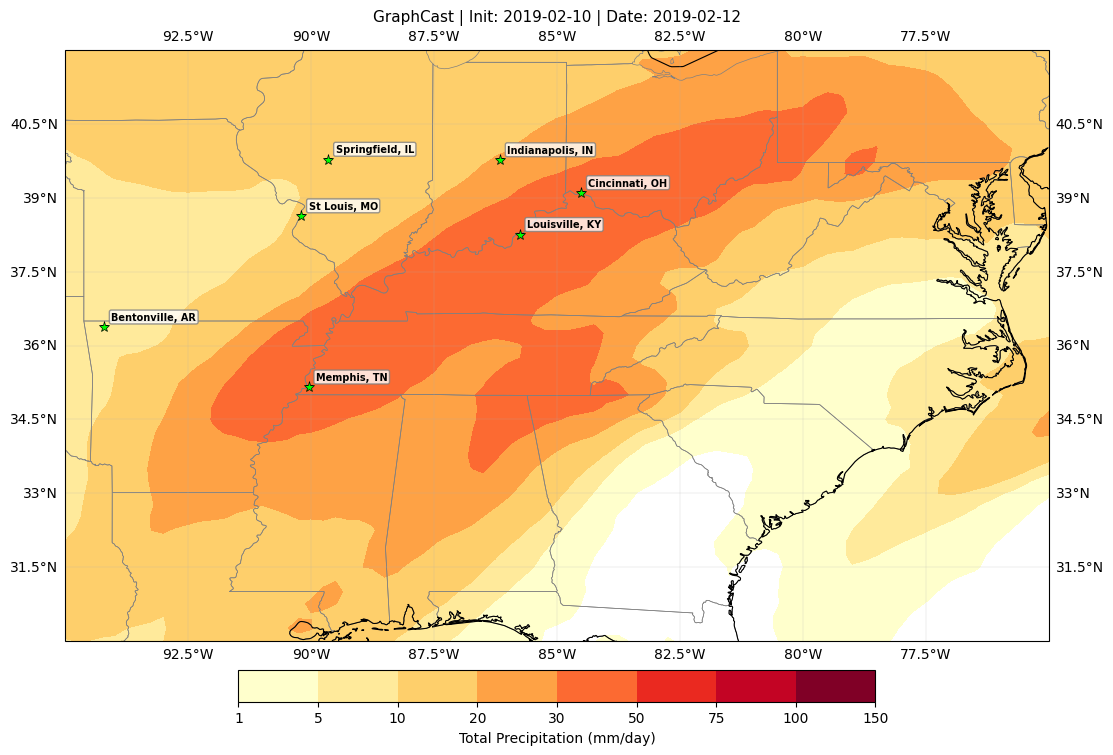

In [10]:
precip_feb12 = compute_daily_total_precip(io, "2019-02-12", FORECAST_INIT)
#poi = {"lat": POI_LAT, "lon": POI_LON, "label": POI_LABEL}

plot_daily_precip(
    precip_feb12, io, "2019-02-12", EXTENT, FORECAST_INIT, poi=CITIES,
    save_path=f"{OUTPUT_DIR}/graphcast_daily_precip_feb12_5day.png",
)

In [11]:
precip_feb12 = compute_daily_total_precip(io, "2019-02-12", FORECAST_INIT)

lat_idx = np.argmin(np.abs(io["lat"][:] - POI_LAT))
lon_idx = np.argmin(np.abs(io["lon"][:] - POI_LON))

print(f"GraphCast total at Louisville on Feb 12: {precip_feb12[lat_idx, lon_idx]:.2f} mm")
print(f"Observed at Louisville on Feb 12: 31.2 mm")

GraphCast total at Louisville on Feb 12: 40.74 mm
Observed at Louisville on Feb 12: 31.2 mm


In [12]:
lat_idx = np.argmin(np.abs(io["lat"][:] - POI_LAT))
lon_idx = np.argmin(np.abs(io["lon"][:] - POI_LON))

dates = ["2019-02-10", "2019-02-11", "2019-02-12", "2019-02-13", "2019-02-14"]
observed = [6.6, 39.1, 31.2, 0.0, 0.0]  # from SDF station, converted to mm

for date, obs in zip(dates, observed):
    precip = compute_daily_total_precip(io, date, FORECAST_INIT)
    fcst = precip[lat_idx, lon_idx]
    print(f"{date} | GraphCast: {fcst:6.2f} mm | Observed: {obs:5.1f} mm")

2019-02-10 | GraphCast:   7.25 mm | Observed:   6.6 mm
2019-02-11 | GraphCast:  26.23 mm | Observed:  39.1 mm
2019-02-12 | GraphCast:  40.74 mm | Observed:  31.2 mm
2019-02-13 | GraphCast:   1.25 mm | Observed:   0.0 mm
2019-02-14 | GraphCast:   0.12 mm | Observed:   0.0 mm


## Multi-Panel Lead Time Progression

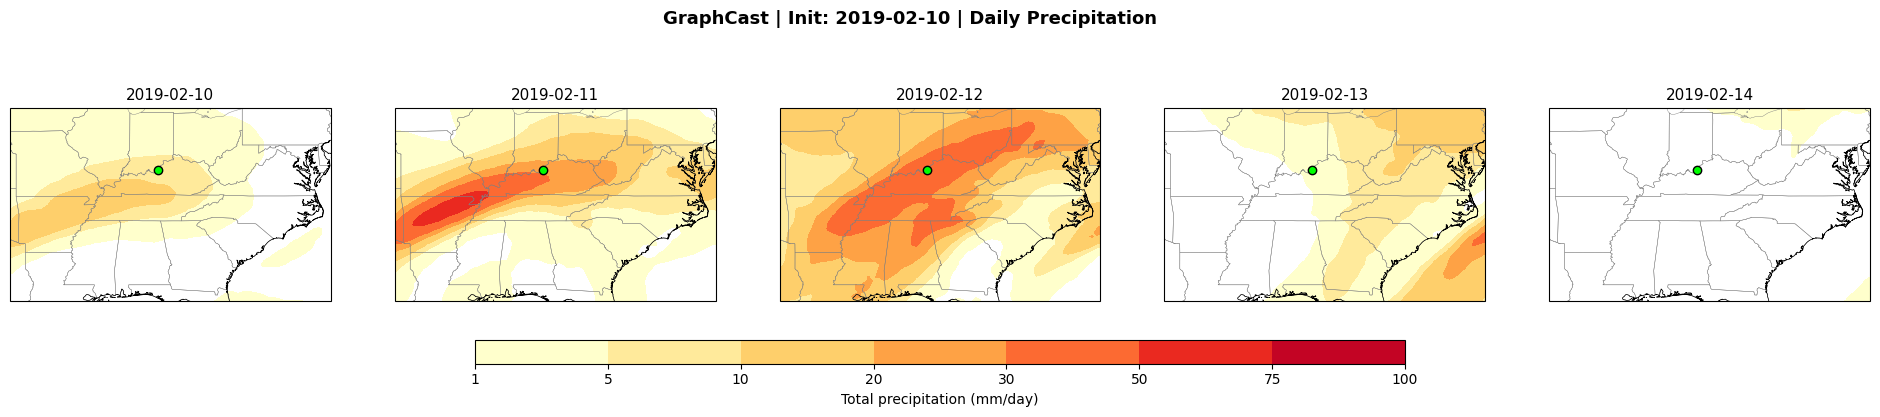

In [79]:
dates = ["2019-02-10", "2019-02-11", "2019-02-12", "2019-02-13", "2019-02-14"]

fig, axes = plt.subplots(
    1, 5,
    subplot_kw={"projection": ccrs.PlateCarree()},
    figsize=(24, 5),
)

levels = [1, 5, 10, 20, 30, 50, 75, 100]
cmap = plt.cm.YlOrRd
norm = mcolors.BoundaryNorm(levels, cmap.N, extend="max")
lon = io["lon"][:]
lat = io["lat"][:]
poi = {"lat": POI_LAT, "lon": POI_LON, "label": POI_LABEL}

for i, date in enumerate(dates):
    ax = axes[i]
    precip = compute_daily_total_precip(io, date, FORECAST_INIT)

    im = ax.contourf(
        lon, lat, precip,
        levels=levels, cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree(), extend="neither",
    )

    ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor="gray")
    ax.coastlines(linewidth=0.5)
    ax.set_extent(EXTENT)
    ax.plot(
        poi["lon"] - 360, poi["lat"],
        marker="o", color="lime", markersize=6,
        markeredgecolor="black", markeredgewidth=1,
        transform=ccrs.PlateCarree(), zorder=5,
    )
    ax.set_title(date, fontsize=11)

fig.subplots_adjust(bottom=0.22)
cbar = fig.colorbar(im, ax=axes, shrink=0.5, pad=0.12, orientation="horizontal", aspect=40)
cbar.set_label("Total precipitation (mm/day)")
fig.suptitle(f"GraphCast | Init: {FORECAST_INIT[:10]} | Daily Precipitation", fontsize=13, fontweight="bold")
fig.savefig(f"{OUTPUT_DIR}/graphcast_daily_feb10_14.png", dpi=150, bbox_inches="tight")
plt.show()

Saved: ohio_flood_outputs/graphcast_daily_2019-02-10.png


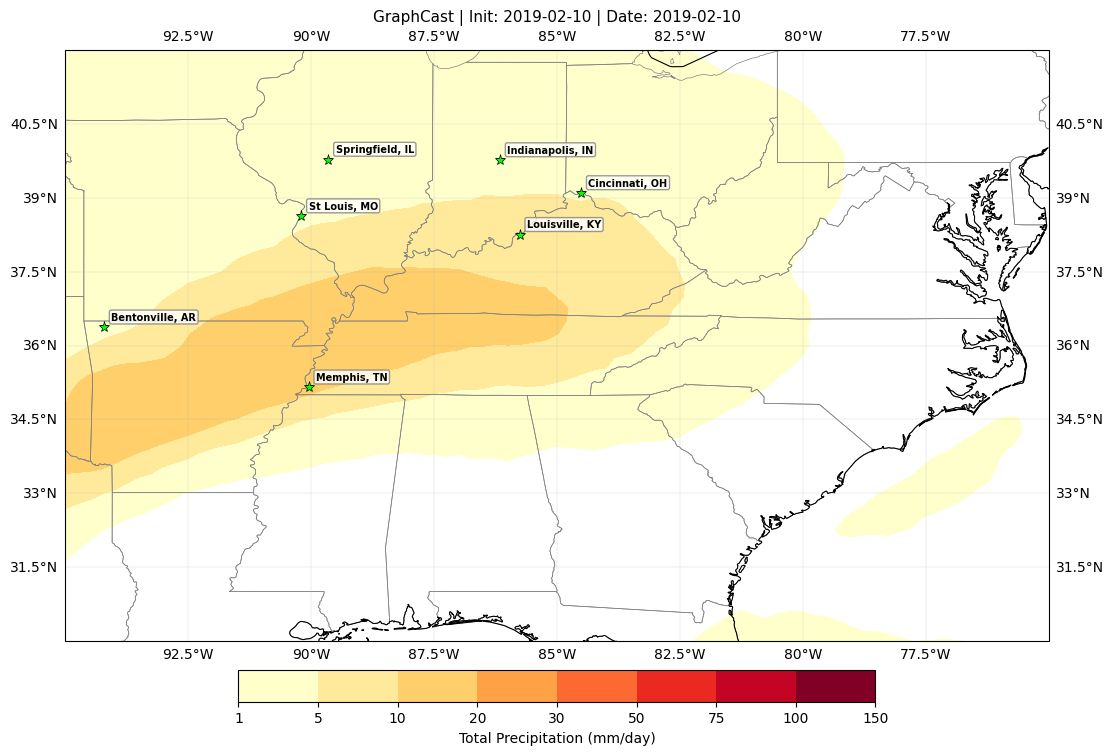

Saved: ohio_flood_outputs/graphcast_daily_2019-02-11.png


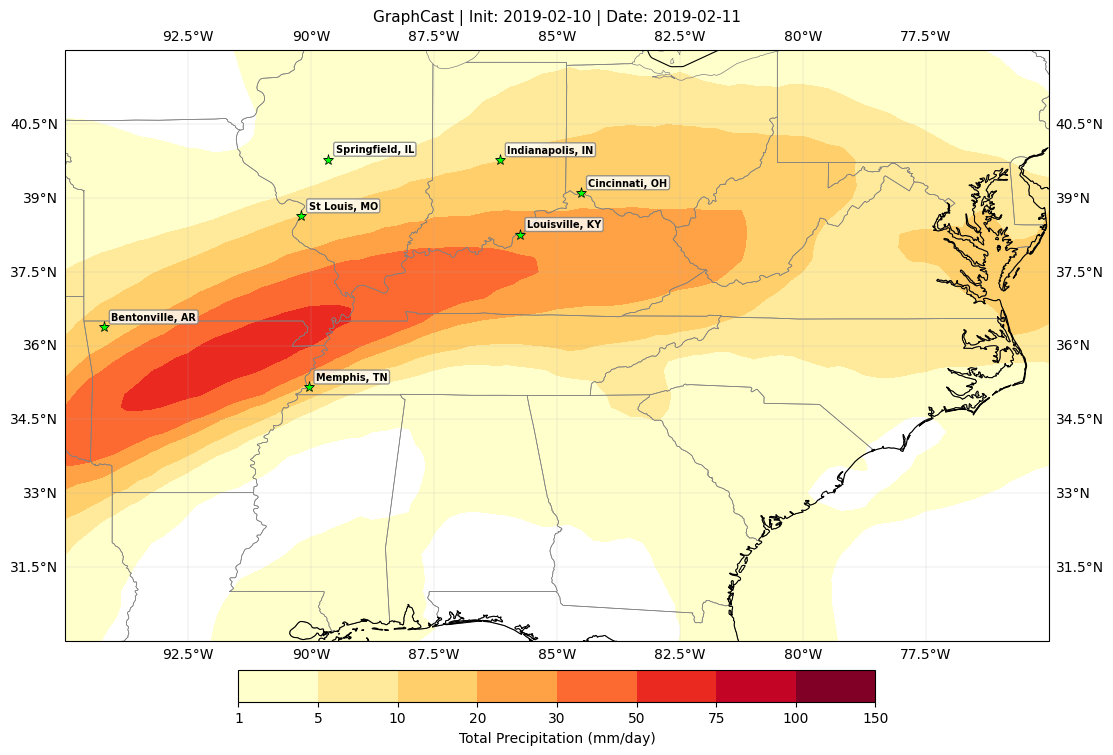

Saved: ohio_flood_outputs/graphcast_daily_2019-02-12.png


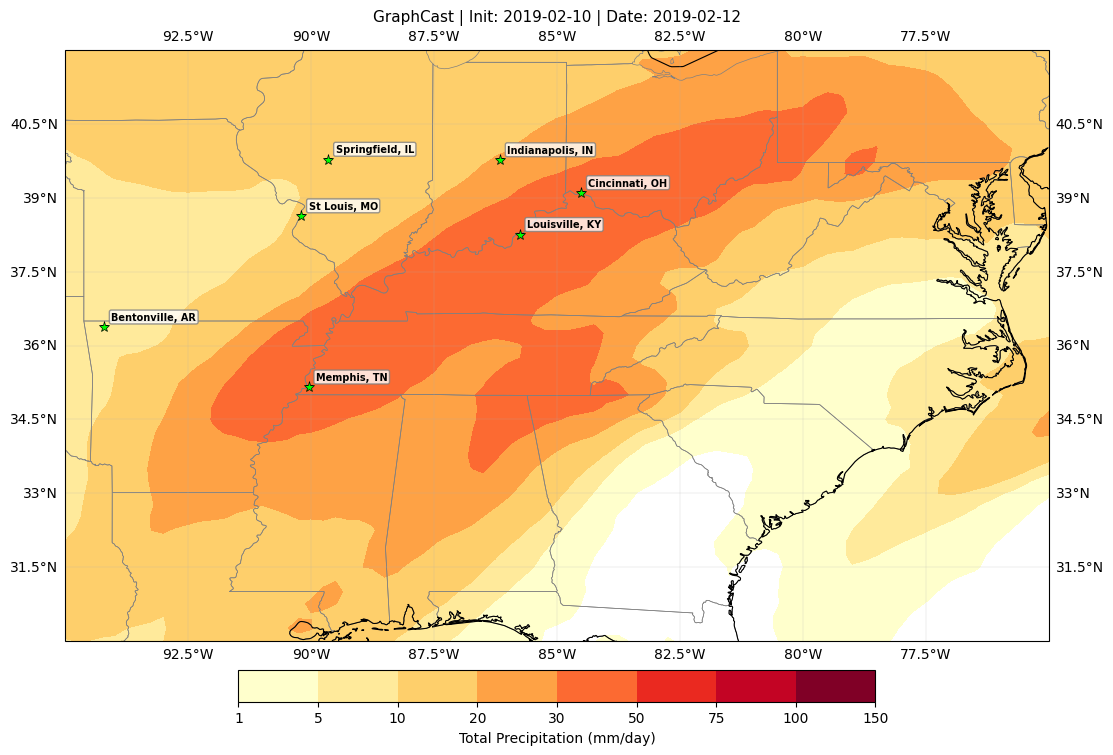

Saved: ohio_flood_outputs/graphcast_daily_2019-02-13.png


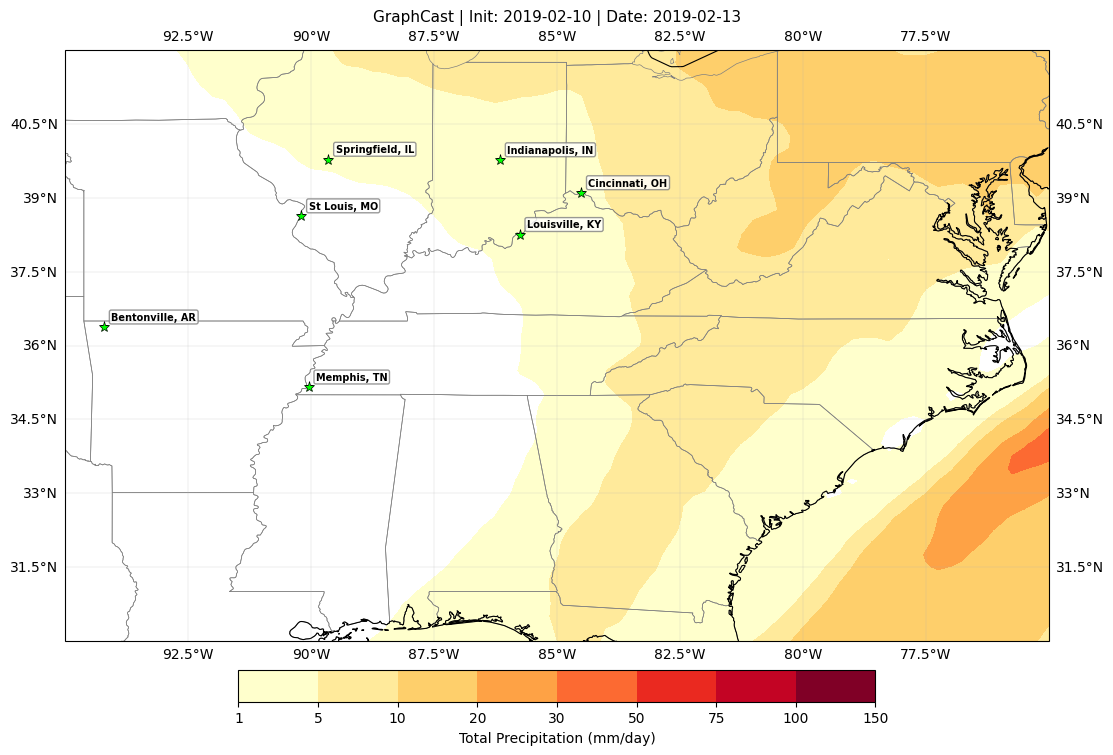

Saved: ohio_flood_outputs/graphcast_daily_2019-02-14.png


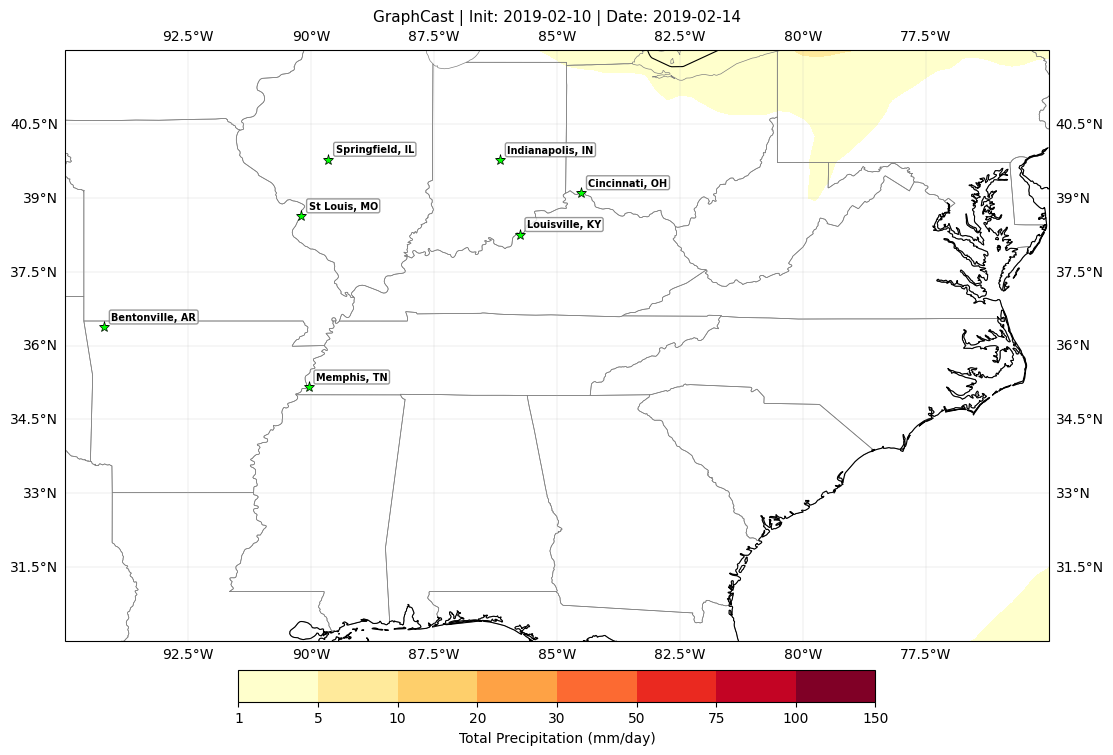

In [13]:
for date in DATES:
    precip = compute_daily_total_precip(io, date, FORECAST_INIT)
    plot_daily_precip(
        precip, io, date, EXTENT, FORECAST_INIT, poi=CITIES,
        save_path=f"{OUTPUT_DIR}/graphcast_daily_{date}.png",
    )